In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [3]:
# 1. Kütüphane İçe Aktarımları
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

print("Gerekli kütüphaneler başarıyla içe aktarıldı.")



Gerekli kütüphaneler başarıyla içe aktarıldı.


## 2. CRM Veri Temizliği (Data Cleaning) & Veri Tipi Optimizasyonu

Bu adımda, ham veri setindeki eksik değerler temizlenir, `CustomerID` sütunu doğru tiplere dönüştürülerek ondalıklı gösterimden arındırılır. Ayrıca, hatalı `Quantity` ve `UnitPrice` değerleri filtrelenir ve `InvoiceDate` sütunu `datetime` formatına çevrilerek `TotalAmount` hesaplanır.

In [4]:
# Veriyi kopyala
df = online_retail.data.original.copy()

print("--- 2. CRM Veri Temizliği (Data Cleaning) & Veri Tipi Optimizasyonu ---")
# CustomerID sütunundaki eksik (NaN) değerleri sil
df.dropna(subset=['CustomerID'], inplace=True)

# KRİTİK ADIM: CustomerID'yi önce tam sayıya (int), sonra metne (string/object) çevirme.
# Ondalıklı görünümlerden (örn: 12345.0) kurtulur ve modelin bunu sayısal bir büyüklük sanmasını engeller.
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# Quantity ve UnitPrice sütunlarında 0 veya sıfırdan küçük (iptal/iade/hatalı) olan satırları filtrele
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# InvoiceDate sütununu datetime formatına çevir
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Toplam harcamayı hesaplamak için TotalAmount (Quantity * UnitPrice) sütununu ekle
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Veri temizliği ve tipi optimizasyonu tamamlandı.")
print("Temizlenmiş Verinin İlk 5 Satırı:")
print(df.head())

--- 2. CRM Veri Temizliği (Data Cleaning) & Veri Tipi Optimizasyonu ---
Veri temizliği ve tipi optimizasyonu tamamlandı.
Temizlenmiş Verinin İlk 5 Satırı:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55      17850  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39      17850  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75      17850  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39      17850  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     

## 3. Özgün Özellik Mühendisliği (CRM & RFM Metrikleri)

Bu adımda, her müşterinin geçmiş davranışını özetleyen `Recency`, `Frequency` ve `Monetary` (RFM) metrikleri hesaplanır. Ayrıca, bir sonraki ayın satış miktarını tahmin etmek için `NextMonthQuantity` adında bir hedef değişken oluşturulur ve veri sızıntısını önlemek amacıyla `shift(-1)` işlemi sonrası oluşan `NaN` değerleri temizlenir. Son olarak, modelin kullanacağı `PreviousMonthQuantity` özelliği eklenir.

In [5]:
print("--- 3. Özgün Özellik Mühendisliği (CRM & RFM Metrikleri) ---")
# Veri setindeki son faturadan bir gün sonrasını referans tarih olarak alıyoruz.
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Recency (Yenilik) hesaplama: Müşterinin son alışverişinden bu yana geçen gün sayısı
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days

# Frequency (Sıklık) hesaplama: Müşterinin toplam tekil fatura sayısı
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

# Monetary (Parasal Değer) hesaplama: Müşterinin bıraktığı toplam ciro
monetary_df = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()
monetary_df.rename(columns={'TotalAmount': 'Monetary'}, inplace=True)

# RFM metriklerini birleştirme
rfm_df = recency_df[['CustomerID', 'Recency']].merge(frequency_df, on='CustomerID')
rfm_df = rfm_df.merge(monetary_df, on='CustomerID')

print("RFM Metrikleri hesaplandı. İlk 5 satırı:")
print(rfm_df.head())

# Aylık Dönüşüm (Target Değişken) Oluşturma
# 'InvoiceYearMonth' sütunu oluşturma (dönem formatında)
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Müşteri ve ürüne göre aylık toplam Quantity'yi hesaplama
monthly_sales = df.groupby(['CustomerID', 'StockCode', 'InvoiceYearMonth'])['Quantity'].sum().reset_index()
monthly_sales.rename(columns={'Quantity': 'MonthlyQuantity'}, inplace=True)

# 'InvoiceYearMonth' sütununu tekrar datetime formatına çevirme (tarih karşılaştırmaları için)
monthly_sales['InvoiceYearMonth'] = monthly_sales['InvoiceYearMonth'].dt.to_timestamp()

# Hedef değişken (bir sonraki ayın MonthlyQuantity'si) oluşturma
# Her CustomerID ve StockCode grubunda bir sonraki aya kaydırma işlemi yapılır.
monthly_sales['NextMonthQuantity'] = monthly_sales.groupby(['CustomerID', 'StockCode'])['MonthlyQuantity'].shift(-1)

# KRİTİK ADIM: shift(-1) işlemi sonucunda zaman serisinin en son ayında oluşan NaN (bilinmeyen gelecek)
# değerleri içeren satırları veri setinden tamamen sil (dropna). Bu, veri sızıntısını önler.
monthly_sales.dropna(subset=['NextMonthQuantity'], inplace=True)

# Hedef değişkeni ondalıklı formattan kurtararak tam sayıya (integer) çevir
monthly_sales['NextMonthQuantity'] = monthly_sales['NextMonthQuantity'].astype(int)

print("Aylık dönüşüm hedef değişkeni oluşturuldu ve NaN değerler temizlendi. İlk 5 satırı:")
print(monthly_sales.head())

# RFM metriklerini monthly_sales DataFrame'ine ekle
# CustomerID tiplerinin eşleştiğinden emin ol (önceki adımda stringe çevrilmişti)
monthly_sales['CustomerID'] = monthly_sales['CustomerID'].astype(str)
df_ml = monthly_sales.merge(rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary']], on='CustomerID', how='left')

# Model için 'PreviousMonthQuantity' (geçmiş ay verisi) özelliğini ekle
df_ml['PreviousMonthQuantity'] = df_ml.groupby(['CustomerID', 'StockCode'])['MonthlyQuantity'].shift(1)

# PreviousMonthQuantity için oluşan NaN değerleri temizle (ilk ay verileri için)
df_ml.dropna(subset=['PreviousMonthQuantity'], inplace=True)

print("\nModel için özellikler (RFM ve PreviousMonthQuantity) eklendi. İlk 5 satırı:")
print(df_ml.head())

--- 3. Özgün Özellik Mühendisliği (CRM & RFM Metrikleri) ---
RFM Metrikleri hesaplandı. İlk 5 satırı:
  CustomerID  Recency  Frequency  Monetary
0      12346      326          1  77183.60
1      12347        2          7   4310.00
2      12348       75          4   1797.24
3      12349       19          1   1757.55
4      12350      310          1    334.40
Aylık dönüşüm hedef değişkeni oluşturuldu ve NaN değerler temizlendi. İlk 5 satırı:
   CustomerID StockCode InvoiceYearMonth  MonthlyQuantity  NextMonthQuantity
4       12347     20719       2011-01-01               10                 10
5       12347     20719       2011-08-01               10                 10
6       12347     20719       2011-10-01               10                 10
12      12347     21041       2011-01-01                6                  6
14      12347     21064       2010-12-01                6                 24

Model için özellikler (RFM ve PreviousMonthQuantity) eklendi. İlk 5 satırı:
  CustomerID Stoc

## 4. Zaman Serisi Bölümlemesi (Time-Based Train/Test Split)

Bu adımda, veri seti zaman bazlı olarak eğitim, doğrulama (validation) ve test setlerine ayrılır. Bu, modelin gelecekteki veriler üzerindeki performansını daha gerçekçi bir şekilde değerlendirmek ve veri sızıntısını önlemek için kritik öneme sahiptir.

In [6]:
print("--- 4. Zaman Serisi Bölümlemesi (Time-Based Train/Test Split) ---")
# Veri setindeki en son ayı belirle
max_month = df_ml['InvoiceYearMonth'].max()

# Test seti: En son ay
test_month = max_month
# Doğrulama (Validation) seti: Sondan bir önceki ay
val_month = max_month - pd.DateOffset(months=1)

# Not: Kullanıcının "son 30 günü" ve "ondan önceki 30 günü" ifadesi, aylık bazda gruplanmış
# 'InvoiceYearMonth' sütunumuz olduğu için sırasıyla son ay ve sondan bir önceki ay olarak yorumlanmıştır.

# Veri setlerini bölme
train_df_ml = df_ml[df_ml['InvoiceYearMonth'] < val_month]
val_df_ml = df_ml[df_ml['InvoiceYearMonth'] == val_month]
test_df_ml = df_ml[df_ml['InvoiceYearMonth'] == test_month]

# Özellik ve hedef değişkenleri tanımla
features = ['Recency', 'Frequency', 'Monetary', 'PreviousMonthQuantity']
target = 'NextMonthQuantity'

X_train, y_train = train_df_ml[features], train_df_ml[target]
X_val, y_val = val_df_ml[features], val_df_ml[target]
X_test, y_test = test_df_ml[features], test_df_ml[target]

print(f"Eğitim Seti Boyutu: {len(X_train)}")
print(f"Doğrulama Seti Boyutu: {len(X_val)}")
print(f"Test Seti Boyutu: {len(X_test)}")

print("Veri setleri zaman bazlı olarak başarıyla bölümlendi.")

--- 4. Zaman Serisi Bölümlemesi (Time-Based Train/Test Split) ---
Eğitim Seti Boyutu: 34477
Doğrulama Seti Boyutu: 4174
Test Seti Boyutu: 2501
Veri setleri zaman bazlı olarak başarıyla bölümlendi.


## 5. Regresyon Modellemesi (Ensemble)

Bu adımda, `Random Forest Regressor` ve `Gradient Boosting Regressor` olmak üzere iki farklı regresyon modeli eğitilir. Bu modellerin tahminleri birleştirilerek (ensemble) daha sağlam ve genellenebilir bir tahmin elde edilir. Negatif tahminler, miktar negatif olamayacağı için 0 olarak düzeltilir.

In [7]:
print("--- 5. Regresyon Modellemesi (Ensemble) ---")
# Random Forest Regressor modelini eğitme
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 tüm çekirdekleri kullanır
rf_model.fit(X_train, y_train)

# Gradient Boosting Regressor modelini eğitme
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Test seti üzerinde tahminler yapma
rf_predictions = rf_model.predict(X_test)
gb_predictions = gb_model.predict(X_test)

# İki modelin tahminlerinin aritmetik ortalamasını alarak bir topluluk (Ensemble) tahmini üretme
ensemble_predictions = (rf_predictions + gb_predictions) / 2

# Negatif tahminleri 0 olarak düzeltme (Miktar negatif olamaz)
ensemble_predictions[ensemble_predictions < 0] = 0

print("Random Forest ve Gradient Boosting Regressor modelleri eğitildi ve ensemble tahminler üretildi.")

--- 5. Regresyon Modellemesi (Ensemble) ---
Random Forest ve Gradient Boosting Regressor modelleri eğitildi ve ensemble tahminler üretildi.


## 6. Performans Değerlendirme & Görselleştirme

Son adımda, ensemble modelin test seti üzerindeki performansı R-squared (R²) ve Mean Absolute Error (MAE) metrikleri ile değerlendirilir. Ayrıca, gelecek ay en çok satış getirmesi beklenen ilk 10 ürün ve en yüksek hacim yaratacak ilk 10 müşteri, Seaborn bar grafikleri kullanılarak görselleştirilir.

--- 6. Performans Değerlendirme & Görselleştirme ---
Model Performansı (Test Seti):
  R-squared (R²): 0.4519
  Mean Absolute Error (MAE): 20.10


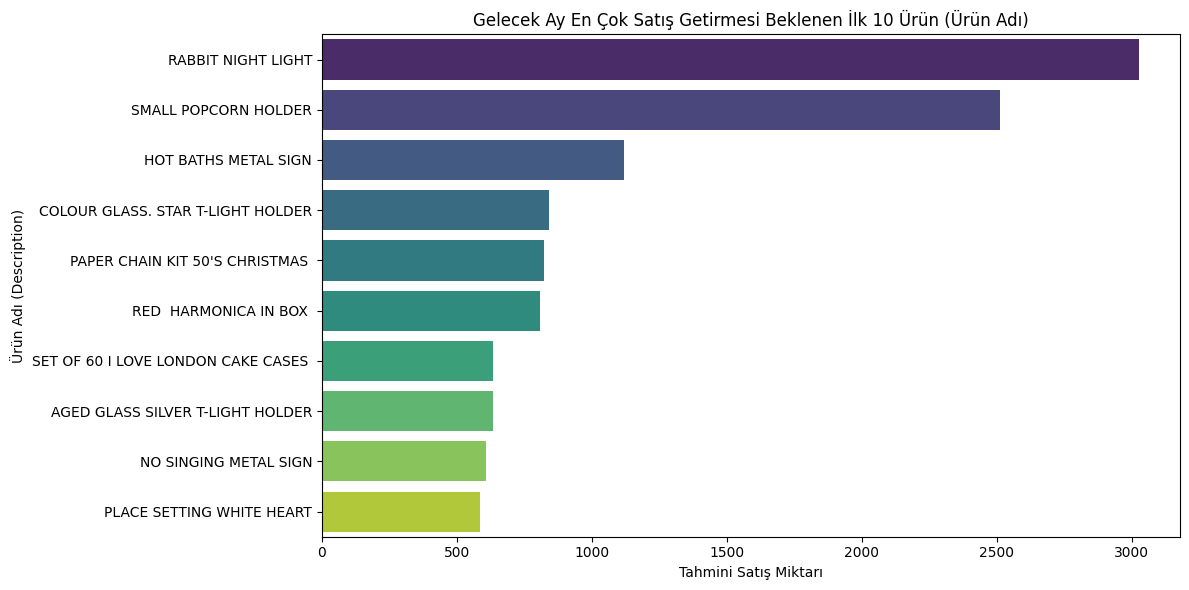

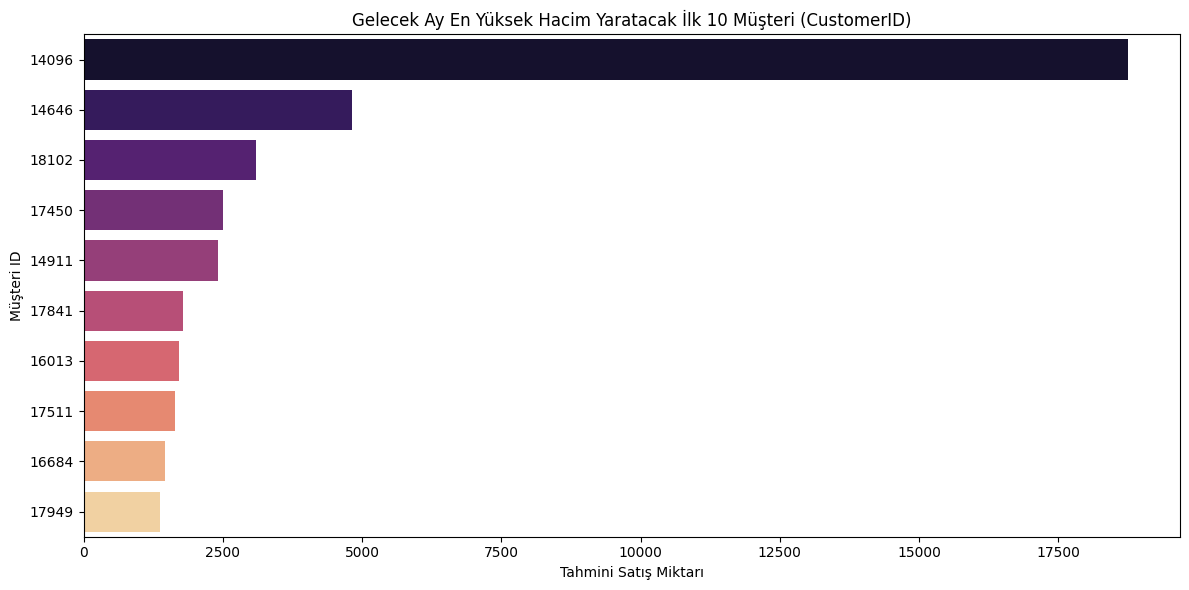

Model performansı değerlendirildi ve görselleştirmeler tamamlandı.


In [8]:
print("--- 6. Performans Değerlendirme & Görselleştirme ---")
# Test seti üzerinde R-squared (R^2 Score) metriğini hesapla
r2 = r2_score(y_test, ensemble_predictions)
# Test seti üzerinde Mean Absolute Error (MAE) metriğini hesapla
mae = mean_absolute_error(y_test, ensemble_predictions)

print(f"Model Performansı (Test Seti):\n  R-squared (R²): {r2:.4f}\n  Mean Absolute Error (MAE): {mae:.2f}")

# Ensemble modelin tahminlerine dayanarak; gelecek ay en çok satış getirmesi beklenen ilk 10 ürünü gösteren bar grafiği çiz.
# Tahminleri ve gerçek değerleri bir DataFrame'de birleştir
test_results = test_df_ml.copy()
test_results['PredictedNextMonthQuantity'] = ensemble_predictions

# Ürün açıklamalarını ana df'den alıp test_results ile birleştirme
# Her StockCode için tek bir Description olduğundan emin olmak için drop_duplicates kullanıyoruz.
product_descriptions = df[['StockCode', 'Description']].drop_duplicates(subset=['StockCode'])
test_results = test_results.merge(product_descriptions, on='StockCode', how='left')

# Ürün bazında toplam beklenen satışları hesapla (StockCode ve Description birlikte gruplanır)
product_sales = test_results.groupby(['StockCode', 'Description'])['PredictedNextMonthQuantity'].sum().reset_index()
product_sales = product_sales.sort_values(by='PredictedNextMonthQuantity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='PredictedNextMonthQuantity', y='Description', data=product_sales, palette='viridis')
plt.title('Gelecek Ay En Çok Satış Getirmesi Beklenen İlk 10 Ürün (Ürün Adı)')
plt.xlabel('Tahmini Satış Miktarı')
plt.ylabel('Ürün Adı (Description)')
plt.tight_layout()
plt.show()

# Gelecek ay en yüksek hacim yaratacak ilk 10 müşteriyi gösteren bar grafiği çiz.
# Müşteri bazında toplam beklenen satışları hesapla
customer_sales = test_results.groupby('CustomerID')['PredictedNextMonthQuantity'].sum().reset_index()
customer_sales = customer_sales.sort_values(by='PredictedNextMonthQuantity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='PredictedNextMonthQuantity', y='CustomerID', data=customer_sales, palette='magma')
plt.title('Gelecek Ay En Yüksek Hacim Yaratacak İlk 10 Müşteri (CustomerID)')
plt.xlabel('Tahmini Satış Miktarı')
plt.ylabel('Müşteri ID')
plt.tight_layout()
plt.show()

print("Model performansı değerlendirildi ve görselleştirmeler tamamlandı.")


## 7. En Çok Satış Getirmesi Beklenen Ürünlerin Müşteri Personaları Analizi

Bu bölümde, en çok satış getirmesi beklenen ürünleri hangi müşteri segmentlerinin (personalrın) satın aldığını analiz edeceğiz. Bu sayede, pazarlama stratejilerini bu personalara özel olarak şekillendirebilir ve ürün yerleştirmeyi optimize edebiliriz. RFM (Recency, Frequency, Monetary) segmentasyonunu kullanarak, her bir "en çok satan" ürünün müşteri tabanının demografik özelliklerini (davranışsal açıdan) anlamaya çalışacağız.
```

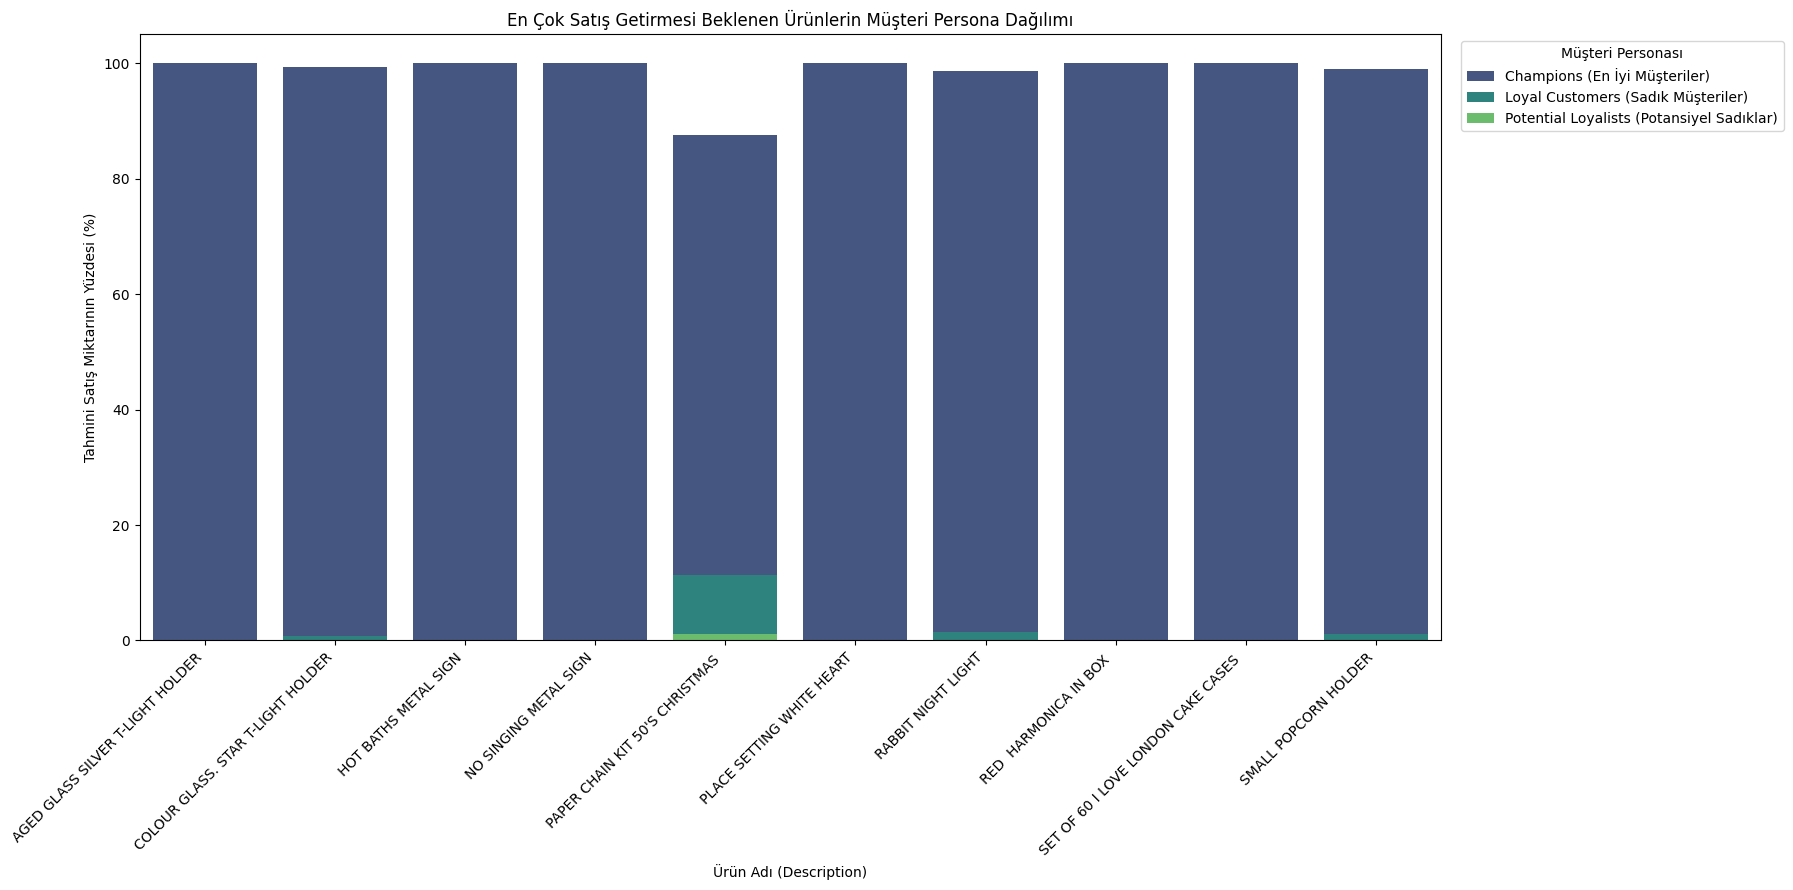

In [11]:
# En çok satış getirmesi beklenen ürünlerin StockCode'larını al
# product_sales DataFrame'inden en çok satan ürünlerin StockCode'larını listeye alır.
top_product_stockcodes = product_sales['StockCode'].tolist()

# --- Müşteri Personalarını Tanımlama ve Veriye Ekleme ---
# RFM skorlarına göre müşteri personalarını atayan fonksiyon
def assign_rfm_persona(df):
    # Champions: Yüksek yenilik, sıklık ve parasal değer
    if (df['R_Score'] == 5) and (df['F_Score'] == 5) and (df['M_Score'] == 5):
        return 'Champions (En İyi Müşteriler)'
    # Loyal Customers: Yüksek sıklık ve parasal değer, iyi yenilik
    elif (df['R_Score'] >= 4) and (df['F_Score'] >= 4) and (df['M_Score'] >= 4):
        return 'Loyal Customers (Sadık Müşteriler)'
    # Potential Loyalists: İyi yenilik, ortalama sıklık ve parasal değer
    elif (df['R_Score'] >= 4) and (df['F_Score'] >= 2) and (df['M_Score'] >= 2):
        return 'Potential Loyalists (Potansiyel Sadıklar)'
    # New Customers: Yüksek yenilik, düşük sıklık ve parasal değer
    elif (df['R_Score'] == 5) and (df['F_Score'] <= 2) and (df['M_Score'] <= 2):
        return 'New Customers (Yeni Müşteriler)'
    # At Risk - High Value: Düşük yenilik, yüksek sıklık ve parasal değer (kaybetme riski yüksek, değerli müşteriler)
    elif (df['R_Score'] <= 2) and (df['F_Score'] >= 4) and (df['M_Score'] >= 4):
        return 'At Risk - High Value (Yüksek Değerli, Riski Müşteriler)'
    # At Risk: Düşük yenilik, ortalama sıklık ve parasal değer (kaybetme riski olanlar)
    elif (df['R_Score'] <= 2) and (df['F_Score'] >= 3) and (df['M_Score'] >= 3):
        return 'At Risk (Riski Müşteriler)'
    # Need Attention: Ortalamanın altında yenilik, ortalama sıklık ve parasal değer (ilgiye ihtiyaç duyanlar)
    elif (df['R_Score'] >= 3) and (df['F_Score'] >= 2) and (df['M_Score'] >= 2):
        return 'Need Attention (İlgiye İhtiyaç Duyanlar)'
    # Hibernating: Çok düşük yenilik, sıklık ve parasal değer (uyuyan müşteriler)
    elif (df['R_Score'] <= 2) and (df['F_Score'] <= 2) and (df['M_Score'] <= 2):
        return 'Hibernating (Uyuyan Müşteriler)'
    # Others: Diğer tüm kategoriler
    else:
        return 'Other (Diğer)'

# RFM skorlarını hesapla (1-5 arası)
# Recency için ters puanlama (daha düşük Recency, daha yüksek puan)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
# Frequency için doğru puanlama (daha yüksek Frequency, daha yüksek puan)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
# Monetary için doğru puanlama (daha yüksek Monetary, daha yüksek puan)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# rfm_df DataFrame'ine 'Persona' sütununu ekle
rfm_df['Persona'] = rfm_df.apply(assign_rfm_persona, axis=1)

# test_results_with_rfm DataFrame'ini, güncellenmiş rfm_df'den 'Persona' bilgisi ile tekrar birleştir
# Bu, her müşterinin kişiliğini analiz etmek için gereklidir.
test_results_with_rfm = test_results.merge(rfm_df[['CustomerID', 'Persona']], on='CustomerID', how='left', suffixes=('', '_new'))
# Eğer yeni birleştirmeden Persona_new oluştuysa, onu Persona olarak kullan
if 'Persona_new' in test_results_with_rfm.columns:
    test_results_with_rfm['Persona'] = test_results_with_rfm['Persona_new']
    test_results_with_rfm.drop(columns=['Persona_new'], inplace=True)

# Sadece en çok satış getirmesi beklenen ürünleri içeren test sonuçlarını filtrele
# test_results_with_rfm DataFrame'ini top_product_stockcodes listesindeki ürünlere göre filtreler.
top_products_customer_data = test_results_with_rfm[test_results_with_rfm['StockCode'].isin(top_product_stockcodes)]

# Her bir top ürün için RFM persona dağılımını hesapla
# Her ürün (Description) için Persona'lara göre tahmini satış miktarını gruplar.
persona_analysis = top_products_customer_data.groupby(['Description', 'Persona'])['PredictedNextMonthQuantity'].sum().reset_index()

# Her ürün için RFM personalarının yüzdelik dağılımını bul (görselleştirme için daha anlamlı)
# Her ürün için toplam tahmini satış miktarını hesaplar.
total_sales_per_product = persona_analysis.groupby('Description')['PredictedNextMonthQuantity'].sum().reset_index(name='TotalPredictedSales')
# Yüzdelik dağılımı hesaplamak için persona_analysis'i toplam satışlarla birleştirir.
persona_analysis = persona_analysis.merge(total_sales_per_product, on='Description')
# Her RFM personasının, ilgili ürünün toplam satışındaki payını hesaplar.
persona_analysis['Percentage'] = (persona_analysis['PredictedNextMonthQuantity'] / persona_analysis['TotalPredictedSales']) * 100

# Görselleştirme: En çok satan ürünler için müşteri persona dağılımı (Stacked Bar Chart)
plt.figure(figsize=(18, 9))
# Her bir ürün için müşteri personalarının tahmini satış yüzdesini yığılmış çubuk grafiği ile gösterir.
sns.barplot(x='Description', y='Percentage', hue='Persona', data=persona_analysis, palette='viridis', dodge=False)
plt.title('En Çok Satış Getirmesi Beklenen Ürünlerin Müşteri Persona Dağılımı') # Grafiğin başlığı.
plt.xlabel('Ürün Adı (Description)') # X ekseni etiketi.
plt.ylabel('Tahmini Satış Miktarının Yüzdesi (%)') # Y ekseni etiketi.
plt.xticks(rotation=45, ha='right') # X ekseni etiketlerini döndürür.
plt.legend(title='Müşteri Personası', bbox_to_anchor=(1.01, 1), loc='upper left') # Lejantı dışarıya alır.
plt.tight_layout() # Düzenin sıkışık olmamasını sağlar.
plt.show() # Grafiği gösterir.

```markdown
## 8. Müşteri Personalarının Karakteristik Isı Haritası

Bu bölümde, her bir müşteri personasının ortalama RFM (Recency, Frequency, Monetary) skorlarını bir ısı haritası ile görselleştirerek personaların karakteristik özelliklerini daha detaylı inceleyeceğiz. Bu, her bir persona grubunun davranışsal eğilimlerini net bir şekilde ortaya koyacaktır.
```

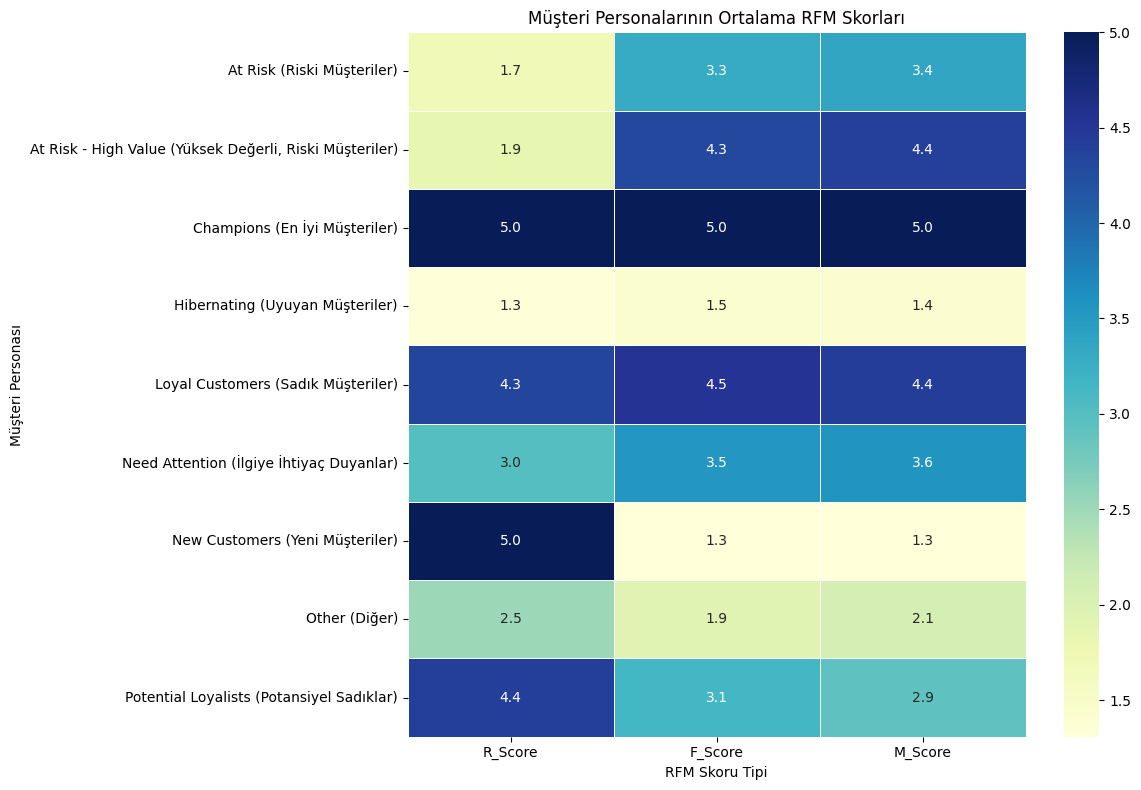

Persona karakteristiği ısı haritası oluşturuldu ve PDF raporu için grafikler kaydedildi.


In [12]:
# Her bir persona'nın ortalama RFM skorlarını hesapla
# rfm_df DataFrame'inden 'Persona'ya göre gruplayıp, R_Score, F_Score, M_Score'un ortalamasını alır.
# 'R_Score', 'F_Score', 'M_Score' sütunlarını kategorik tipinden sayısal tipe (int) dönüştürerek mean() fonksiyonunun çalışmasını sağla.
persona_rfm_avg = rfm_df.groupby('Persona')[['R_Score', 'F_Score', 'M_Score']].apply(lambda x: x.astype(int).mean()).reset_index()

# Persona isimlerini görselleştirme için hazırla
# Persona isimlerini indeks olarak ayarlar.
persona_rfm_heatmap_data = persona_rfm_avg.set_index('Persona')

# Isı haritasını oluştur
plt.figure(figsize=(12, 8))
# Seaborn heatmap kullanarak personaların ortalama RFM skorlarını görselleştirir.
sns.heatmap(persona_rfm_heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5)
plt.title('Müşteri Personalarının Ortalama RFM Skorları') # Grafiğin başlığı.
plt.xlabel('RFM Skoru Tipi') # X ekseni etiketi.
plt.ylabel('Müşteri Personası') # Y ekseni etiketi.
plt.tight_layout() # Düzenin sıkışık olmamasını sağlar.
plt.show() # Grafiği gösterir.

# PDF raporu için gerekli grafikleri kaydet
# En Çok Satış Getirmesi Beklenen Ürünlerin Müşteri Persona Dağılımı grafiğini yeniden oluştur ve kaydet
# Önceki hücrede oluşturulan persona_analysis ve top_product_stockcodes değişkenleri kullanılmaktadır.
fig_product_dist = plt.figure(figsize=(18, 9))
sns.barplot(x='Description', y='Percentage', hue='Persona', data=persona_analysis, palette='viridis', dodge=False)
plt.title('En Çok Satış Getirmesi Beklenen Ürünlerin Müşteri Persona Dağılımı')
plt.xlabel('Ürün Adı (Description)')
plt.ylabel('Tahmini Satış Miktarının Yüzdesi (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Müşteri Personası', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
fig_product_dist.savefig('persona_product_distribution.png')
plt.close(fig_product_dist) # Bellek kullanımını optimize etmek için grafiği kapat

# Müşteri Personalarının Ortalama RFM Skorları ısı haritasını kaydet
fig_rfm_heatmap = plt.figure(figsize=(12, 8))
sns.heatmap(persona_rfm_heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5)
plt.title('Müşteri Personalarının Ortalama RFM Skorları')
plt.xlabel('RFM Skoru Tipi')
plt.ylabel('Müşteri Personası')
plt.tight_layout()
fig_rfm_heatmap.savefig('persona_rfm_heatmap.png')
plt.close(fig_rfm_heatmap) # Bellek kullanımını optimize etmek için grafiği kapat

print("Persona karakteristiği ısı haritası oluşturuldu ve PDF raporu için grafikler kaydedildi.")

In [13]:
# fpdf2 kütüphanesini yükle
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 15.6 MB/s eta 0:00:00


In [14]:
import requests

def download_font(url, filename):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Successfully downloaded {filename}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {filename} from {url}: {e}")



regular_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf"
bold_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-Bold.ttf"
italic_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-Italic.ttf"
bold_italic_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-BoldItalic.ttf"


download_font(regular_url, 'NotoSans-Regular.ttf')
download_font(bold_url, 'NotoSans-Bold.ttf')
download_font(italic_url, 'NotoSans-Italic.ttf')
download_font(bold_italic_url, 'NotoSans-BoldItalic.ttf')

print("Noto Sans fontları indirme denemesi tamamlandı.")

Successfully downloaded NotoSans-Regular.ttf
Successfully downloaded NotoSans-Bold.ttf
Successfully downloaded NotoSans-Italic.ttf
Successfully downloaded NotoSans-BoldItalic.ttf
Noto Sans fontları indirme denemesi tamamlandı.


In [15]:
from fpdf import FPDF
from IPython.display import FileLink
from google.colab import files # Import files for direct download

# PDF sınıfını tanımla
class PDF(FPDF):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # İndirilen Noto Sans fontlarını ekle
        self.add_font('NotoSans', '', 'NotoSans-Regular.ttf', uni=True)
        self.add_font('NotoSans', 'B', 'NotoSans-Bold.ttf', uni=True)
        self.add_font('NotoSans', 'I', 'NotoSans-Italic.ttf', uni=True)
        self.add_font('NotoSans', 'BI', 'NotoSans-BoldItalic.ttf', uni=True)
        self.default_font = 'NotoSans'
        self.set_font(self.default_font, '', 12)

    def header(self):
        # Rapor başlığı
        self.set_font(self.default_font, 'B', 15)
        self.cell(0, 10, 'Pazarlama Stratejisi Raporu', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        # Sayfa numarası
        self.set_y(-15)
        self.set_font(self.default_font, 'I', 8)
        self.cell(0, 10, f'Sayfa {self.page_no()}/{{nb}}', 0, 0, 'C')

    def chapter_title(self, title):
        # Bölüm başlığı
        self.set_font(self.default_font, 'B', 12)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(5)

    def chapter_body(self, body):
        # Bölüm metni
        self.set_font(self.default_font, '', 10)
        self.multi_cell(0, 5, body)
        self.ln(5)

    def add_image_from_file(self, image_path, title=None, width=180):
        # PDF'e görsel ekleme
        if title:
            self.set_font(self.default_font, 'I', 10)
            self.cell(0, 7, title, 0, 1, 'C')
            self.ln(2)
        self.image(image_path, x=self.get_x() + (210 - width) / 2, w=width) # Görseli ortala
        self.ln(10)

# PDF objesini oluştur
pdf = PDF()
pdf.alias_nb_pages()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

# Rapor Başlığı
pdf.set_font(pdf.default_font, 'B', 16)
pdf.cell(0, 10, 'Müşteri Personaları ve Pazarlama Stratejisi Raporu', 0, 1, 'C')
pdf.ln(10)

# 1. Giriş Bölümü
pdf.chapter_title('1. Giriş')
intro_text = """Bu rapor, online perakende verileri üzerinden yapılan analizler sonucunda elde edilen müşteri personaları ve bu personalara yönelik pazarlama stratejilerini sunmaktadır. RFM (Recency, Frequency, Monetary) metrikleri kullanılarak oluşturulan personalar, müşteri davranışlarını anlamak ve hedefli kampanyalar geliştirmek için önemli içgörüler sağlamaktadır. Amacımız, en çok satış getiren ürünleri hangi müşteri gruplarının tercih ettiğini belirleyerek daha verimli pazarlama kampanyaları yürütmektir.\n"""
pdf.chapter_body(intro_text)

# 2. Müşteri Personalarının Karakteristikleri Bölümü
pdf.chapter_title('2. Müşteri Personalarının Karakteristikleri')
persona_char_text = """Aşağıdaki ısı haritası, tanımlanan her bir müşteri personasının ortalama RFM skorlarını göstermektedir. Bu skorlar, her bir persona grubunun 'yenilik' (Recency), 'sıklık' (Frequency) ve 'parasal değer' (Monetary) açısından genel eğilimlerini özetlemektedir. Örneğin, 'Champions' personaları tüm skorlarda yüksek değerlere sahipken, 'Hibernating' personaları genellikle düşük skorlara sahiptir. Bu görselleştirme, her bir persona'nın temel davranışsal özelliklerini anlamamızı sağlar.\n"""
pdf.chapter_body(persona_char_text)
pdf.add_image_from_file('persona_rfm_heatmap.png', title='Şekil 1: Müşteri Personalarının Ortalama RFM Skorları')

# 3. En Çok Satılan Ürünlerin Persona Bazında Dağılımı Bölümü
pdf.chapter_title('3. En Çok Satılan Ürünlerin Persona Bazında Dağılımı')
top_products_text = """Aşağıdaki yığılmış çubuk grafik, en çok satış getirmesi beklenen ürünlerin hangi müşteri personaları tarafından daha yoğun olarak satın alındığını göstermektedir. Bu analiz, belirli ürünler için hedef kitleleri belirlememize ve ürünlerin hangi persona grupları arasında popüler olduğunu anlamamıza yardımcı olur. Bu sayede, ürün tanıtımlarını doğru kitleye yönlendirebiliriz.\n"""
pdf.chapter_body(top_products_text)
pdf.add_image_from_file('persona_product_distribution.png', title='Şekil 2: En Çok Satış Getirmesi Beklenen Ürünlerin Müşteri Persona Dağılımı')

# 4. Pazarlama Stratejileri Bölümü
pdf.chapter_title('4. Pazarlama Stratejileri')

strategy_text_champions = """\n**4.1. Champions (En İyi Müşteriler):**\nBu müşteriler şirketinizin en değerli segmentidir. Yüksek yenilik, sıklık ve parasal değere sahiplerdir. Onları elde tutmak ve ödüllendirmek kritik öneme sahiptir.\n*   **Strateji:** Özel indirimler, sadakat programları, yeni ürün lansmanlarına erken erişim ve kişiselleştirilmiş teşekkür mesajları ile değerlerini hissettirin. Çapraz satış (cross-selling) ve üst satış (up-selling) fırsatları sunun.\n*   **Amaç:** Marka bağlılığını artırmak, yaşam boyu değerlerini yükseltmek ve ağızdan ağıza pazarlamayı teşvik etmek.\n"""
pdf.chapter_body(strategy_text_champions)

strategy_text_loyalists = """\n**4.2. Loyal Customers (Sadık Müşteriler):**\nDengeli bir şekilde düzenli alışveriş yapan ve iyi bir parasal değere sahip müşterilerdir.\n*   **Strateji:** Sürekli sadakat programları, özel müşteri etkinlikleri ve geri bildirim mekanizmaları ile ilişkilerini derinleştirin.\n*   **Amaç:** Sadakatlerini pekiştirmek ve 'Champions' seviyesine geçmelerini teşvik etmek.\n"""
pdf.chapter_body(strategy_text_loyalists)

strategy_text_potential_loyalists = """\n**4.3. Potential Loyalists (Potansiyel Sadıklar):**\nSon zamanlarda alışveriş yapmış, ancak sıklık ve parasal değeri artırma potansiyeli olan müşterilerdir.\n*   **Strateji:** İkinci alışveriş teşvikleri, kişiselleştirilmiş ürün önerileri ve fayda odaklı içerik pazarlaması.\n*   **Amaç:** Müşteri yolculuğunu ilerletmek ve onları sadık müşterilere dönüştürmek.\n"""
pdf.chapter_body(strategy_text_potential_loyalists)

strategy_text_new_customers = """\n**4.4. New Customers (Yeni Müşteriler):**\nYeni edinilen müşterilerdir ve sadık müşterilere dönüşme potansiyelleri vardır.\n*   **Strateji:** Hoş geldin e-postaları serisi, ürün kullanım kılavuzları, ilk sipariş indirimleri ve temel ürün kategorileri hakkında bilgilendirme. Müşteri desteği ile hızlı etkileşim fırsatları sunun.\n*   **Amaç:** Müşteri deneyimini iyileştirmek, ilk satın alma sonrası sadakati inşa etmek ve tekrar alım oranını artırmak.\n"""
pdf.chapter_body(strategy_text_new_customers)

strategy_text_at_risk = """\n**4.5. At Risk (Riski Müşteriler) / At Risk - High Value (Yüksek Değerli, Riski Müşteriler):**\nSon zamanlarda daha az alışveriş yapan, ancak geçmişte değerli olan müşterilerdir. Düşük yenilik, ortalama veya yüksek sıklık/parasal değere sahip olabilirler.\n*   **Strateji:** Tekrar aktif hale getirme kampanyaları (örn. özel teklifler, ilgi çekici ürün önerileri, ücretsiz kargo), kayıp nedenlerini anlamak için geri bildirim anketleri. Yüksek değerli riskli müşterilere daha agresif ve kişiselleştirilmiş teklifler sunulabilir.\n*   **Amaç:** Müşterileri kaybetmeden önce yeniden etkileşim kurmak ve churn oranını düşürmek.\n"""
pdf.chapter_body(strategy_text_at_risk)

strategy_text_hibernating = """\n**4.6. Hibernating (Uyuyan Müşteriler):**\nUzun zamandır alışveriş yapmayan ve düşük sıklık/parasal değere sahip müşterilerdir. İşletme için düşük maliyetli geri dönüş potansiyeline sahiptirler.\n*   **Strateji:** Düşük maliyetli yeniden etkileşim kampanyaları, özel gün hatırlatıcıları veya çok cazip, sınırlı süreli teklifler. Geçmiş satın alma alışkanlıklarına göre yeniden hedefleme.\n*   **Amaç:** Küçük bir kısmı bile yeniden canlandırılabilirse kar sağlayabilir.\n"""
pdf.chapter_body(strategy_text_hibernating)

strategy_text_attention = """\n**4.7. Need Attention (İlgiye İhtiyaç Duyanlar):**\nOrtalamanın altında yenilik, ancak iyi sıklık ve parasal değere sahip müşterilerdir. Yeniliklerini artırmak önemlidir.\n*   **Strateji:** Yeniliklerini artırmaya yönelik hatırlatıcı e-postalar, yeni gelen ürünler hakkında bilgi verme ve geçmiş satın alımlarına dayalı öneriler.\n*   **Amaç:** Müşteri etkileşimini ve yeniliğini artırmak.\n"""
pdf.chapter_body(strategy_text_attention)

# 5. Sonuç Bölümü
pdf.chapter_title('5. Sonuç')
conclusion_text = """Müşteri personalarına dayalı bu stratejiler, pazarlama çabalarınızı daha verimli hale getirmenize ve her müşteri segmentinin özel ihtiyaçlarına göre yanıt vermenize olanak tanır. Elde edilen içgörülerle, kişiselleştirilmiş iletişim ve tekliflerle müşteri memnuniyeti ve satışları artırabilir, böylece genel iş performansınızı iyileştirebilirsiniz.\n"""
pdf.chapter_body(conclusion_text)

# PDF dosyasını kaydet ve indirme linki oluştur
pdf_file_name = 'Pazarlama_Stratejisi_Raporu.pdf'
pdf.output(pdf_file_name)

print(f"PDF raporu '{pdf_file_name}' oluşturuldu.")
# display(FileLink(pdf_file_name)) # Oluşturulan PDF dosyasını indirmek için link gösterir.
files.download(pdf_file_name) # Doğrudan indirmeyi başlatır.

PDF raporu 'Pazarlama_Stratejisi_Raporu.pdf' oluşturuldu.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>